<a href="https://colab.research.google.com/github/SmileCat42/Deep-Learning/blob/main/Lab13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Lab11**
กฤตยา ตันติชัยยกุล

In [1]:
import kagglehub

# Download latest version

path = kagglehub.dataset_download("karakaggle/kaggle-cat-vs-dog-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'kaggle-cat-vs-dog-dataset' dataset.
Path to dataset files: /kaggle/input/kaggle-cat-vs-dog-dataset


เป็นการเก็บ path ที่อยู่ของไฟล์รูปภาพที่ดาวน์โหลดมาผ่านเว็ป

In [2]:
import os, shutil

original_dataset_dir = os.path.join(path, "kagglecatsanddogs_3367a", "PetImages")

#Cats data set

cat_src_dir = os.path.join(original_dataset_dir, 'Cat')

dog_src_dir = os.path.join(original_dataset_dir, 'Dog')

print(os.path.exists(cat_src_dir)) # check path ว่ามีอยู่จริงไหม true or not

print(os.path.exists(dog_src_dir)) # check true or not

True
True


เป็นการแบ่งตัวแปรเป็น 2 ฝั่ง คือฝั่งแมวกับฝั่งหมา โดยที่ dog_src_dir เข้าถึงพาทของรูปหมา ส่วนcat_src_dir เข้าถึงพาทของรูปแมว

In [3]:
# Directory where you'll store your smaller dataset

base_dir = "/content/cats_and_dogs_small"

if os.path.exists(base_dir): # clear folder
  shutil.rmtree(base_dir)

os.makedirs(base_dir, exist_ok=True)
train_dir = os.path.join(base_dir, 'train')

os.makedirs(train_dir, exist_ok=True)
test_dir = os.path.join(base_dir, 'test')

os.makedirs(test_dir, exist_ok=True)
validation_dir = os.path.join(base_dir, 'validation')

os.makedirs(validation_dir, exist_ok=True)
train_cats_dir = os.path.join(train_dir, 'cats')

os.makedirs(train_cats_dir, exist_ok=True)
train_dogs_dir = os.path.join(train_dir, 'dogs')

os.makedirs(train_dogs_dir, exist_ok=True)
validation_cats_dir = os.path.join(validation_dir, 'cats')

os.makedirs(validation_cats_dir, exist_ok=True)
validation_dogs_dir = os.path.join(validation_dir, 'dogs')

os.makedirs(validation_dogs_dir, exist_ok=True)
test_cats_dir = os.path.join(test_dir, 'cats')

os.makedirs(test_cats_dir, exist_ok=True)
test_dogs_dir = os.path.join(test_dir, 'dogs')

os.makedirs(test_dogs_dir, exist_ok=True)

cat_files = [f for f in os.listdir(cat_src_dir)]

dog_files = [f for f in os.listdir(dog_src_dir)]

เป็นการสร้างโฟลเดอร์ train test รอไว้สำหรับการรอคัดลอกรูปภาพมาใส่


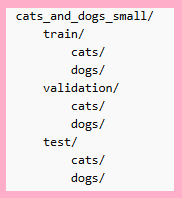

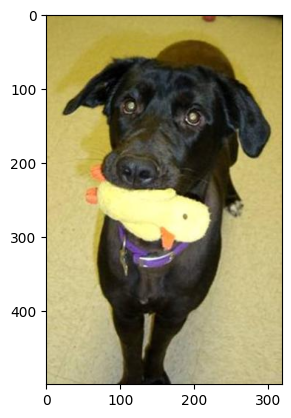

Image size (width, height): (319, 500)
Image shape (height, width, channels): (500, 319, 3)


In [4]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import os

img_path = os.path.join(dog_src_dir, dog_files[500]) #คือการเอาเพิ่ม path ระบุถึงตัวไฟล์เลยว่าเป็นรูปหมาที่ 500

img = Image.open(img_path)

plt.imshow(img)
plt.show()

print("Image size (width, height):", img.size)
print("Image shape (height, width, channels):", np.array(img).shape)

dog_src_dir = โฟลเดอร์ที่เก็บรูปหมา
dog_files[500] = ชื่อไฟล์ลำดับที่ 500
os.path.join() = ต่อ path ให้ถูกต้อง

แล้วจึงนำมา ap.array เพื่อทำให้เป็นตัวเลข เนื่องจาก CNN จะทำงานกับตัวเลข

In [5]:
train_cats = cat_files[:1000]
train_dogs = dog_files[:1000]

val_cats = cat_files[1000:1500]
val_dogs = dog_files[1000:1500]

test_cats = cat_files[1500:2000]
test_dogs = dog_files[1500:2000]

เป็นการแบ่งโครง ยังไม่ได้แตะต้องไฟล์จริง

In [6]:
def copy_files(file_list, src_dir, dst_dir):
  for fname in file_list:
    src = os.path.join(src_dir, fname)
    dst = os.path.join(dst_dir, fname)
    shutil.copyfile(src, dst)

วางคำสั่ง copy เตรียม!!

In [7]:
copy_files(train_cats, cat_src_dir, os.path.join(base_dir, "train", "cats"))
copy_files(val_cats, cat_src_dir, os.path.join(base_dir, "validation", "cats")) #คือการ path มาต่อกันเช่น base_dir = cats_and_dogs_small + /validation + /cats
copy_files(test_cats, cat_src_dir, os.path.join(base_dir, "test", "cats"))
copy_files(train_dogs, dog_src_dir, os.path.join(base_dir, "train", "dogs"))
copy_files(val_dogs, dog_src_dir, os.path.join(base_dir, "validation", "dogs"))
copy_files(test_dogs, dog_src_dir, os.path.join(base_dir, "test", "dogs"))

print("Dataset ready at:", base_dir)
print(len(train_cats), len(val_cats), len(test_cats))
print(len(train_dogs), len(val_dogs), len(test_dogs))

Dataset ready at: /content/cats_and_dogs_small
1000 500 500
1000 500 500


เอา list รายชื่อไฟล์ train_cats

ไปหาไฟล์จริงใน cat_src_dir

copy ไปไว้ที่ base_dir/train/cats

In [8]:
for name in ["train", "validation", "test"]:
  print(os.path.join(base_dir, name, "cats"))
  print(len(os.listdir(os.path.join(base_dir, name, "cats"))))
  print(os.path.join(base_dir, name, "dogs"))
  print(len(os.listdir(os.path.join(base_dir, name, "dogs"))))

/content/cats_and_dogs_small/train/cats
1000
/content/cats_and_dogs_small/train/dogs
1000
/content/cats_and_dogs_small/validation/cats
500
/content/cats_and_dogs_small/validation/dogs
500
/content/cats_and_dogs_small/test/cats
500
/content/cats_and_dogs_small/test/dogs
500


เช็คว่าข้อมูลเท่ากัน

In [9]:
from tensorflow.keras import layers
from tensorflow.keras import models

model = models.Sequential()
model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Conv2D(128, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Conv2D(128, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Flatten())
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


ขยายความสามารถให้ Conv2D ขึ้นทุกๆชั้น ในขณะที่ Maxpooling ทำการย่อรูปให้เล็กลงเรื่อยๆ เพื่อป้องกันการเข้าสู่การ Flatten จะทำให้เกิดพารามิเตอร์มหาศาล ขนาดย่อให้เหลือ 7*7 8*8 ยัง3-4 ล้านตัวเลย

In [10]:
from tensorflow.keras import optimizers

model.compile(
loss='binary_crossentropy',
optimizer=optimizers.RMSprop(learning_rate=1e-4),
metrics=['accuracy']
)

(learning_rate=1e-4) คือขนาดก้าว หรือ 0.0001 ซึ่งถ้าเยอะไปกระโดดแรง loss แกว่ง แต่ถ้าน้อยไปก็เรียนช้า ซึ่ง 0.0001 ถือว่ากำลังดี (เหรอ?555)

In [11]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale=1./255) # ตั้งค่าไว้ก่อน ยังไม่หารจริง
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
  train_dir, #เข้าไปหยิบรูปภายในนี้เพื่อหา cat dog ทีละ 20 รูป
  target_size=(150,150), #แปลงให้เป็น 150*150
  batch_size=20,
  class_mode='binary' #ต้องการคำตอบคือหมาหรือแมว
)

validation_generator = test_datagen.flow_from_directory(
  validation_dir,
  target_size=(150, 150),
  batch_size=20,
  class_mode='binary')

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


แปลงไฟล์ภาพดิบให้เป็นตัวเลข ที่โมเดลเข้าใจได้ ทำให้ทุกรูปเท่ากัน 150*150 rescale=1./255 ซึ่งต่างจากการ Flatten คือ โค้ดนี้จะแปลงรูปก่อนส่งเข้าไปหาโมเดล ขนาดเท่าเดิมเลย แค่ทำให้ค่าข้อมูลเป็นเลข ในขณะที่ Flatten อยู่ข้างในแล้ว จะทำการแปลงเป็น 1 มิติ เพื่อส่งต่อให้ Dense

In [12]:
for data_batch, labels_batch in train_generator:
  print('data batch shape:', data_batch.shape)
  print('labels batch shape:', labels_batch.shape)
  break

data batch shape: (20, 150, 150, 3)
labels batch shape: (20,)


เป็นการเช็คขนาดข้อมูลว่าถูกต้องก่อน fit หรือไม่

In [13]:
history = model.fit(
  train_generator,
  steps_per_epoch=100,
  epochs=7,
  validation_data=validation_generator,
  validation_steps=50)

Epoch 1/7
 99/100 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.4931 - loss: 0.6946

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 59ms/step - accuracy: 0.5165 - loss: 0.6910 - val_accuracy: 0.6160 - val_loss: 0.6792
Epoch 2/7
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step - accuracy: 0.5935 - loss: 0.6689 - val_accuracy: 0.6030 - val_loss: 0.6583
Epoch 3/7
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - accuracy: 0.6205 - loss: 0.6483 - val_accuracy: 0.6370 - val_loss: 0.6432
Epoch 4/7
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - accuracy: 0.6410 - loss: 0.6289 - val_accuracy: 0.6230 - val_loss: 0.6288
Epoch 5/7
100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 56ms/step - accuracy: 0.6685 - loss: 0.5998 - val_accuracy: 0.6570 - val_loss: 0.6000
Epoch 6/7
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - accuracy: 0.7180 - loss: 0.5631 - val_accuracy: 0.6810 - val_loss: 0.5970
Epoch 7/7
100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 57ms/step - accuracy: 0.7270 - loss: 0.5398 - val_accuracy: 0.6860 - val_loss: 0.5798


In [14]:

from tensorflow.keras.models import load_model

model.save('chichi.h5')

#from google.colab import files  #ดาวน์โหลดเข้ามาใน colab
#files.download("cats_and_dogs_small_1.keras")

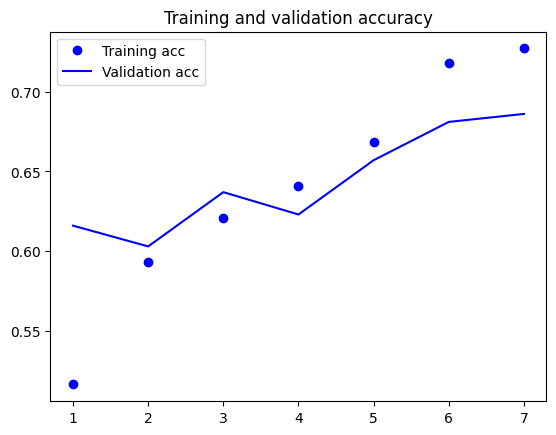

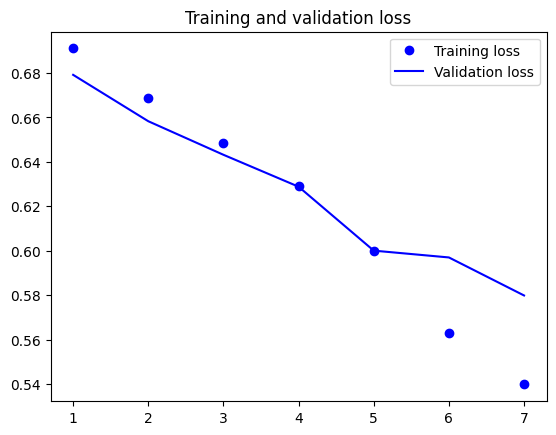

In [15]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']

val_acc = history.history['val_accuracy']

loss = history.history['loss']

val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.plot(epochs, acc, 'bo', label='Training acc')

plt.plot(epochs, val_acc, 'b', label='Validation acc')

plt.title('Training and validation accuracy')

plt.legend()

plt.figure()

#

plt.plot(epochs, loss, 'bo', label='Training loss')

plt.plot(epochs, val_loss, 'b', label='Validation loss')

plt.title('Training and validation loss')

plt.legend()

plt.show()

In [16]:
import os
os.listdir("/content")

['.config', 'cats_and_dogs_small', 'chichi.h5', 'sample_data']

In [17]:
#from google.colab import files
#files.download("cats_and_dogs_small_1.h5")

os เช็คว่ามีไฟล์ที่ชื่อ .h5 อยู่ในโฟลเดอร์ไหม มีแต่พอปิดเว็ปก็หายอยู่ดี เลยต้องโหลดไว้ที่เครื่อง

# **Augment!** For show

In [18]:
datagen = ImageDataGenerator(
  rotation_range=40,
  width_shift_range=0.2,
  height_shift_range=0.2,
  shear_range=0.2,
  zoom_range=0.2,
  horizontal_flip=True,
  fill_mode='nearest')

โค้ดนี้ยังไม่ /255 ไว้สำหรับโชว์ให้คนดูว่าหน้าตาการสร้างภาพใหม่จากเดิม โดยการ Aug เพื่อทำให้โมเดลฝึกได้หลากหลายมากขึ้นเป็นอย่างไร

In [19]:
from tensorflow.keras.preprocessing import image

fnames = [os.path.join(train_cats_dir, fname) for fname in
  os.listdir(train_cats_dir)]

# เลือกภาพ 1 รูป
img_path = fnames[186]

# โหลดภาพ และ resize เป็น 150x150
img = image.load_img(img_path, target_size=(150, 150))

# แปลงเป็น NumPy array (150, 150, 3)
x = image.img_to_array(img)

# reshape เป็น (1, 150, 150, 3) เพราะ datagen ทำงานกับ batch
x = x.reshape((1,) + x.shape)

เอา x ที่จัดเก็บรูปภาพ 186 ที่เราเลือกไปยำไปขยี้จนกลายเป้น รูปขนาด 1*150*150*3 ไปเจนเพื่อให้เกิดการ Augment ภาพหลากหลายมากขึ้น ดังต่อไปนี้

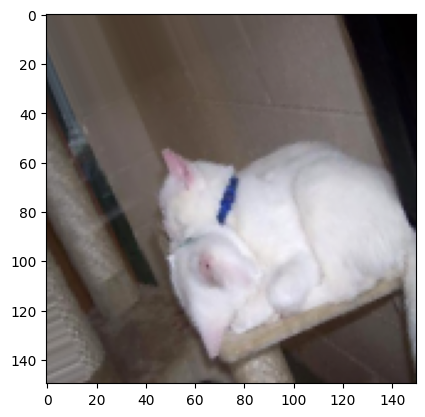

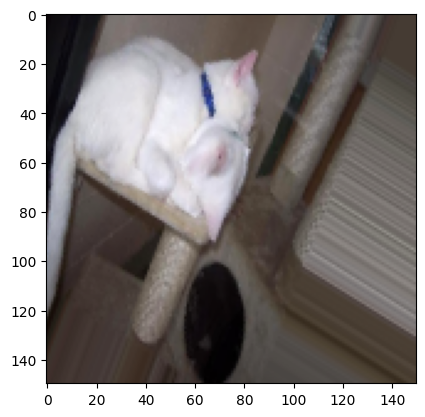

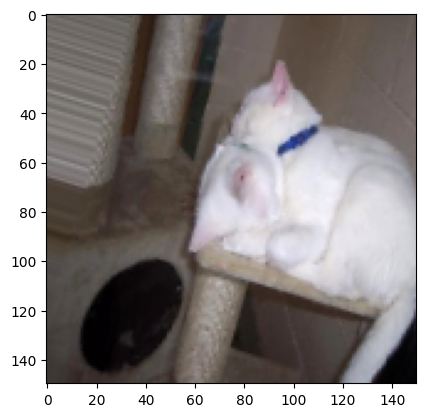

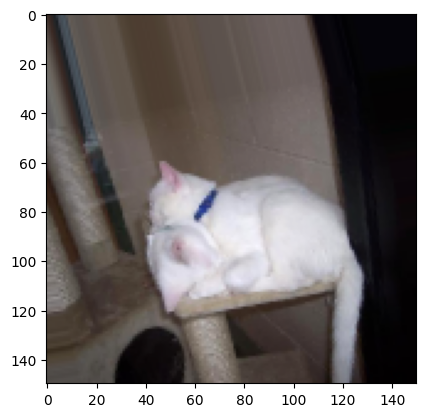

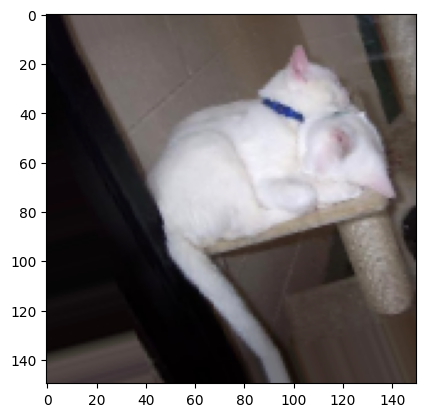

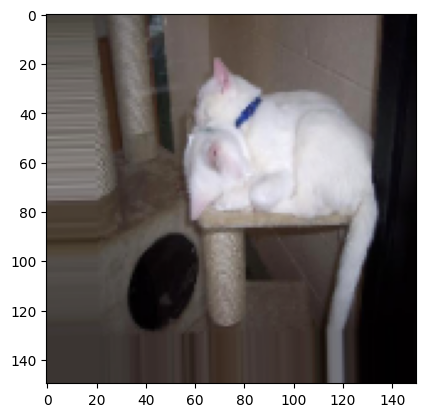

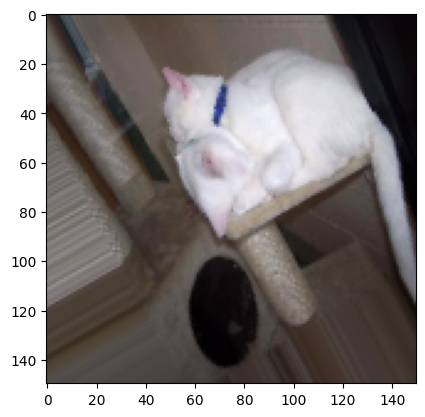

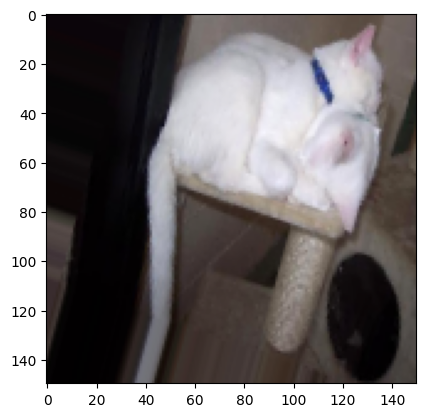

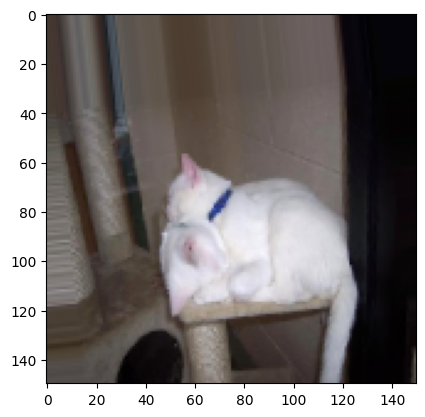

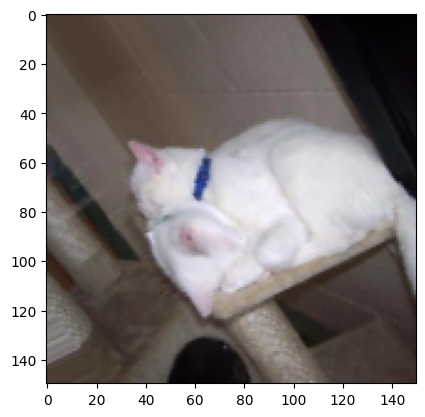

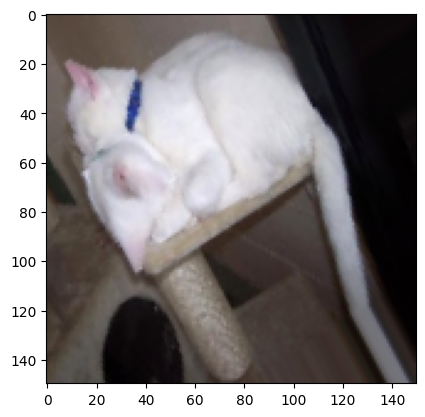

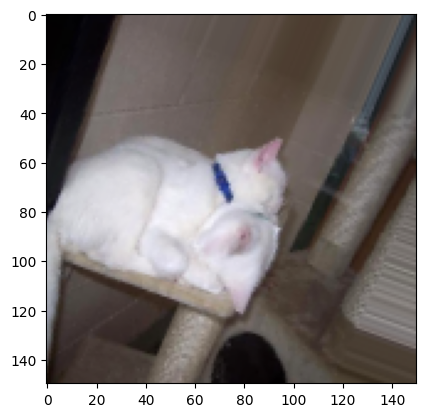

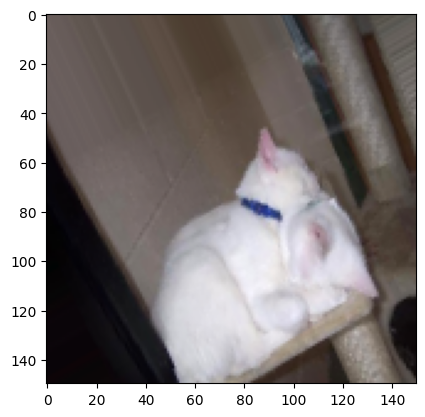

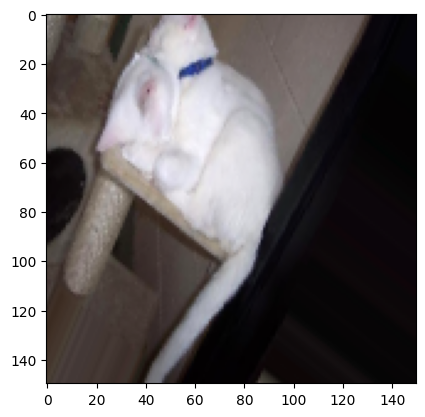

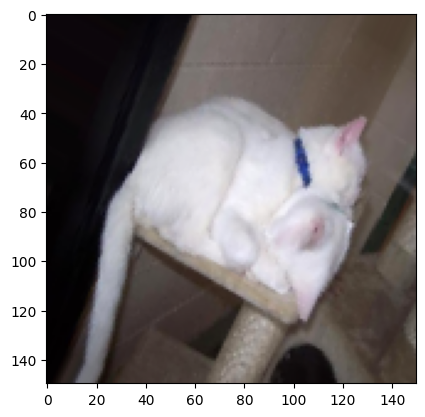

In [20]:
i = 0

for batch in datagen.flow(x, batch_size=1):

  plt.figure(i)

  imgplot = plt.imshow(image.array_to_img(batch[0]))

  i += 1

  if i % 15 == 0:

   break

plt.show()

In [21]:
from tensorflow.keras import optimizers

model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150,
150, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Flatten())
model.add(layers.Dropout(0.5))
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))
model.compile(loss='binary_crossentropy',
optimizer=optimizers.RMSprop(learning_rate=1e-4),
metrics=['accuracy'])

สร้าง model เวอร์ขั่นใหม่ขึ้นมา แบบที่มี dropout

# **Agment! For train**

In [22]:
train_datagen = ImageDataGenerator(
  rescale=1./255,
  rotation_range=40,
  width_shift_range=0.2,
  height_shift_range=0.2,
  shear_range=0.2,
  zoom_range=0.2,
  horizontal_flip=True)

อันนี้คือของจริง /255 สำหรับประเคนให้โมเดลโดยตรง ถ้าเอาโค้ดนี้ไป plot show จะไม่รู้เรื่องแล้วนะ รูปจะเพี้ยนแล้ว

In [23]:
test_datagen = ImageDataGenerator(rescale=1./255)

Test ไม่ต้องเอาไปบดขยี้ แค่ทำ /255 ให้โมเดลอ่านรู้เรื่องพอ

In [24]:
train_generator = train_datagen.flow_from_directory(
  train_dir, #บอกเป้าว่าโฟลเดอร์อยู่ไหน
  target_size=(150, 150),
  batch_size=32,
  class_mode='binary')

validation_generator = test_datagen.flow_from_directory(
  validation_dir,
  target_size=(150, 150),
  batch_size=32,
  class_mode='binary')

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


In [25]:
history = model.fit(
  train_generator,
  steps_per_epoch=100,
  epochs=7,
  validation_data=validation_generator,
  validation_steps=50)

Epoch 1/7
 63/100 ━━━━━━━━━━━━━━━━━━━━ 10s 274ms/step - accuracy: 0.4973 - loss: 0.6950

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


100/100 ━━━━━━━━━━━━━━━━━━━━ 25s 204ms/step - accuracy: 0.4975 - loss: 0.6942 - val_accuracy: 0.5580 - val_loss: 0.6888
Epoch 2/7
100/100 ━━━━━━━━━━━━━━━━━━━━ 17s 170ms/step - accuracy: 0.5335 - loss: 0.6901 - val_accuracy: 0.5700 - val_loss: 0.6840
Epoch 3/7
100/100 ━━━━━━━━━━━━━━━━━━━━ 18s 150ms/step - accuracy: 0.5550 - loss: 0.6837 - val_accuracy: 0.5980 - val_loss: 0.6718
Epoch 4/7
100/100 ━━━━━━━━━━━━━━━━━━━━ 16s 156ms/step - accuracy: 0.5560 - loss: 0.6765 - val_accuracy: 0.6090 - val_loss: 0.6619
Epoch 5/7
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 153ms/step - accuracy: 0.5930 - loss: 0.6682 - val_accuracy: 0.5650 - val_loss: 0.6737
Epoch 6/7
100/100 ━━━━━━━━━━━━━━━━━━━━ 17s 166ms/step - accuracy: 0.5855 - loss: 0.6665 - val_accuracy: 0.5570 - val_loss: 0.6865
Epoch 7/7
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 153ms/step - accuracy: 0.5795 - loss: 0.6666 - val_accuracy: 0.6070 - val_loss: 0.6498


In [26]:
model.save('chichi2.h5')

In [27]:
import os
os.listdir("/content")

['.config', 'chichi2.h5', 'cats_and_dogs_small', 'chichi.h5', 'sample_data']

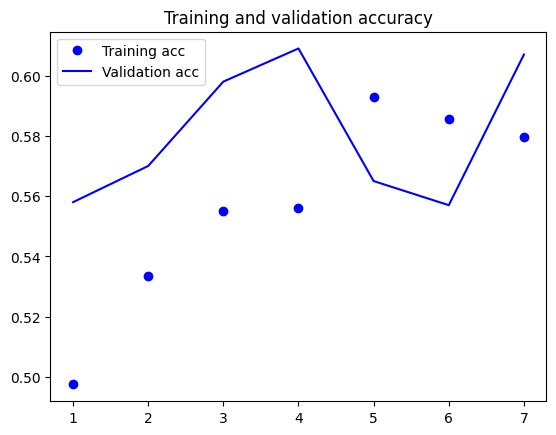

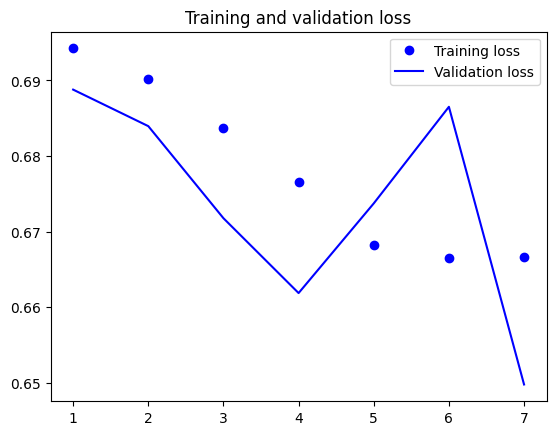

In [28]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']

val_acc = history.history['val_accuracy']

loss = history.history['loss']

val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.plot(epochs, acc, 'bo', label='Training acc')

plt.plot(epochs, val_acc, 'b', label='Validation acc')

plt.title('Training and validation accuracy')

plt.legend()

plt.figure()

plt.plot(epochs, loss, 'bo', label='Training loss')

plt.plot(epochs, val_loss, 'b', label='Validation loss')

plt.title('Training and validation loss')

plt.legend()

plt.show()

In [29]:
import numpy as np
from google.colab import files
from tensorflow.keras.preprocessing import image

# 1. อัปโหลดรูปหมาหรือแมวจากเครื่องคุณ (My Computer)
uploaded = files.upload()

for fn in uploaded.keys():
  # 2. เตรียมรูปภาพ (ต้อง Resize ให้เป็น 150x150 เท่าตอนเทรน)
  path = '/content/' + fn
  img = image.load_img(path, target_size=(150, 150))

  # 3. แปลงรูปภาพเป็นตัวเลข (Array)
  x = image.img_to_array(img)
  x = np.expand_dims(x, axis=0) # เพิ่มมิติให้เป็น (1, 150, 150, 3)
  x /= 255.0                    # อย่าลืมหาร 255 เพื่อทำ Normalize

  # 4. ให้โมเดลทำนาย
  classes = model.predict(x)

  print(f"ค่าที่โมเดลส่งออกมา: {classes[0]}")

  if classes[0] > 0.5:
    print(f"ผลลัพธ์: {fn} คือ 'น้องหมา' 🐶")
  else:
    print(f"ผลลัพธ์: {fn} คือ 'น้องแมว' 🐱")

Saving 14.jpg to 14.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 783ms/step
ค่าที่โมเดลส่งออกมา: [0.77843857]
ผลลัพธ์: 14.jpg คือ 'น้องหมา' 🐶


# **Lab12**

Pretrain วิธีที่ 1

In [30]:
from tensorflow.keras.applications import VGG16

conv_base = VGG16(
weights='imagenet',
include_top=False,
input_shape=(150, 150, 3)
)
conv_base.summary( )

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 150, 150, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 75, 75, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 18, 18, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 9, 9, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

หรือ from keras.applications import VGG16

In [31]:
import os
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator

base_dir = '/Users/fchollet/Downloads/cats_and_dogs_small'
train_dir = os.path.join(base_dir, 'train')
validation_dir = os.path.join(base_dir, 'validation')
test_dir = os.path.join(base_dir, 'test')

datagen = ImageDataGenerator(rescale=1./255)
batch_size = 20

ทำการ reset กติกาใหม่ ลองไม่ใช้ Aug กับโมเดลที่เก่งแล้ว และรองรับได้แค่เฉพาะ 150*150

In [32]:
def extract_features(directory, sample_count):
  features = np.zeros(shape=(sample_count, 4, 4, 512)) #สร้างกล่องเปล่าๆไว้เก็บ feathur
  labels = np.zeros(shape=(sample_count))
  generator = datagen.flow_from_directory( #ดึงรูปผ่านท่อ
    directory,
    target_size=(150, 150),
    batch_size=batch_size,
    class_mode='binary')
  i = 0
  for inputs_batch, labels_batch in generator:
    features_batch = conv_base.predict(inputs_batch) #ทำนาย หาจุดเด่น
    features[i * batch_size : (i + 1) * batch_size] = features_batch #บันทึกลง fethur ท่เราสร้างไว้ตอนแรก
    labels[i * batch_size : (i + 1) * batch_size] = labels_batch
    i += 1
    if i * batch_size >= sample_count:#เมื่อครบ 2000 ก็หยด
      break
  return features, labels

ฟังก์ชั่นสำหรับดำเนินการสกัด สำหรับโมเดลที่เก่งแล้ว

In [33]:
import os

# 1. บังคับกำหนด Path ใหม่ให้ถูกต้อง (สำหรับ Colab)
base_dir = '/content/cats_and_dogs_small'
train_dir = os.path.join(base_dir, 'train')
validation_dir = os.path.join(base_dir, 'validation')
test_dir = os.path.join(base_dir, 'test')

# 2. เช็คให้ชัวร์ว่าเจอโฟลเดอร์จริงไหม (ถ้าไม่เจอจะ print บอก)
if not os.path.exists(train_dir):
    print("❌ ยังหาโฟลเดอร์ไม่เจอ! ตรวจสอบว่าได้รัน Cell ที่ Copy รูปภาพหรือยัง")
else:
    print("✅ เจอโฟลเดอร์แล้ว! เริ่มสกัดฟีเจอร์ได้...")

    # 3. รันคำสั่งเดิมของคุณ
    train_features, train_labels = extract_features(train_dir, 2000)
    validation_features, validation_labels = extract_features(validation_dir, 1000)
    test_features, test_labels = extract_features(test_dir, 1000)

train_features, train_labels = extract_features(train_dir, 2000)
validation_features, validation_labels = extract_features(validation_dir, 1000)
test_features, test_labels = extract_features(test_dir, 1000)

✅ เจอโฟลเดอร์แล้ว! เริ่มสกัดฟีเจอร์ได้...
Found 2000 images belonging to 2 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 

ทำฟังก์ชั่น extract_features() ที่เราประกาศไว้ในการสกัดฟีเจอร์ โดยหยิบมาทีละ 20 รูป ให้โมเดลคนเก่งแสกนรูป แล้วพอได้คำตอบก็ไปใส่ไว้ในฟีเจอร์ที่เราสร้างไว้บรรทัดแรก

In [34]:
train_features = np.reshape(train_features, (2000, 4 * 4 * 512))
validation_features = np.reshape(validation_features, (1000, 4 * 4 * 512))
test_features = np.reshape(test_features, (1000, 4 * 4 * 512))

เอาฟีเจอร์มา Flatten

In [35]:
from keras import models
from keras import layers
from keras import optimizers

model = models.Sequential()
model.add(layers.Dense(256, activation='relu', input_dim = 4 * 4 * 512))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(1, activation='sigmoid'))

model.compile(optimizer=optimizers.RMSprop(learning_rate=2e-5),
              loss='binary_crossentropy',
              metrics=['acc'])

history = model.fit(train_features, train_labels,
epochs=30,
batch_size=20,
validation_data=(validation_features, validation_labels))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - acc: 0.6840 - loss: 0.5778 - val_acc: 0.8130 - val_loss: 0.4677
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - acc: 0.8150 - loss: 0.4276 - val_acc: 0.8190 - val_loss: 0.3957
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - acc: 0.8525 - loss: 0.3557 - val_acc: 0.8480 - val_loss: 0.3601
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - acc: 0.8810 - loss: 0.3149 - val_acc: 0.8590 - val_loss: 0.3418
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - acc: 0.8840 - loss: 0.2904 - val_acc: 0.8570 - val_loss: 0.3279
Epoch 6/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - acc: 0.9020 - loss: 0.2657 - val_acc: 0.8580 - val_loss: 0.3215
Epoch 7/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - acc: 0.9025 - loss: 0.2546 - val_acc: 0.8680 - val_loss: 0.3092
Epoch 8/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - acc: 0.9090 - loss: 0.2401 - val_acc: 0.8690 - val_loss: 0.3032
Epoch 9/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - a

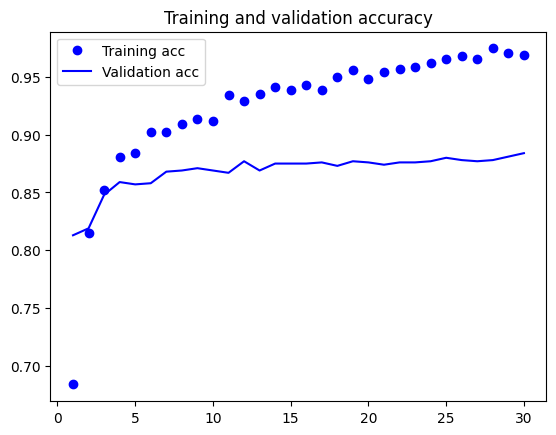

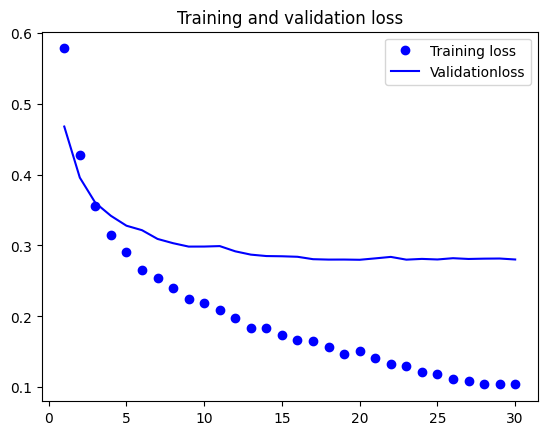

In [36]:
import matplotlib.pyplot as plt

acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

138

plt.figure()

plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validationloss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

จะเห็นว่า overfitting มาก ไม่น่าเวิร์คสำหรับการนำไปสอบ เนื่องจากวิธีนี้ให้เรียนจากภาพนิ่ง ไม่มีการ Aug เลย ทำให้เป็นแบบนี้ (แต่ fit ไวมาก)
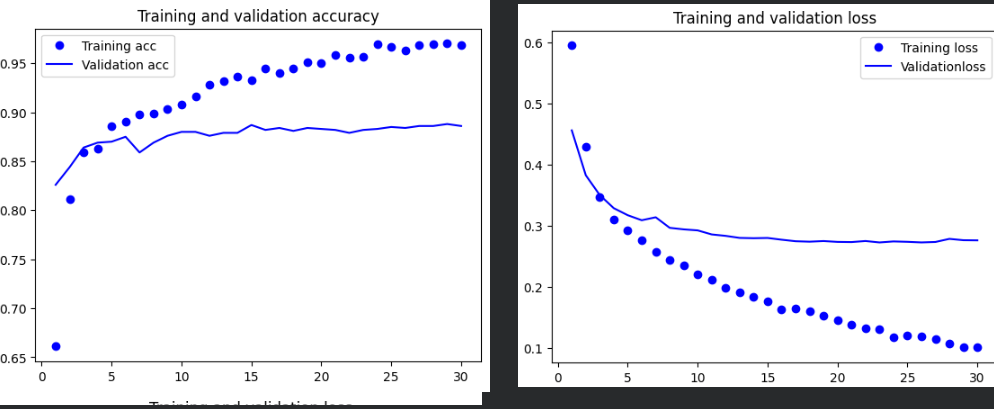

# **วิธีที่ 2**

In [37]:
from keras import models
from keras import layers

model = models.Sequential()
model.add(conv_base)
model.add(layers.Flatten())
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,812,353 (64.13 MB)

 Trainable params: 16,812,353 (64.13 MB)

 Non-trainable params: 0 (0.00 B)

In [38]:
print('This is the number of trainable weights '
... 'before freezing the conv base:', len(model.trainable_weights))

conv_base.trainable = False

print('This is the number of trainable weights '
... 'after freezing the conv base:', len(model.trainable_weights))

This is the number of trainable weights before freezing the conv base: 30
This is the number of trainable weights after freezing the conv base: 4


เป็นการเช็คว่าก่อนแช่มีพารา 30 ตัว หลังแช่มีพาราเหลือแค่ 4 ตัว

In [39]:
ImageDataGenerator(
  rotation_range=40,
  width_shift_range=0.2,
  zoom_range=0.2,
  horizontal_flip=True
)

วิธีนี้สามารถ Aug ได้

In [40]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras import optimizers

train_datagen = ImageDataGenerator(
rescale=1./255,
rotation_range=40,
width_shift_range=0.2,
height_shift_range=0.2,
shear_range=0.2,
zoom_range=0.2,
horizontal_flip=True,
fill_mode='nearest')

test_datagen = ImageDataGenerator(rescale=1./255)

In [41]:
train_generator = train_datagen.flow_from_directory(
train_dir,
target_size=(150, 150),
batch_size=20,
class_mode='binary')

validation_generator = test_datagen.flow_from_directory(
validation_dir,
target_size=(150, 150),
batch_size=20,
class_mode='binary')


model.compile(loss='binary_crossentropy',
optimizer=optimizers.RMSprop(learning_rate=2e-5),
metrics=['acc'])

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


In [42]:
history = model.fit(
train_generator,
steps_per_epoch=100,
epochs=30,
validation_data=validation_generator,
validation_steps=50)

Epoch 1/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 23s 212ms/step - acc: 0.7060 - loss: 0.5838 - val_acc: 0.8060 - val_loss: 0.4585
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 22s 221ms/step - acc: 0.7940 - loss: 0.4783 - val_acc: 0.8410 - val_loss: 0.3827
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 39s 197ms/step - acc: 0.8065 - loss: 0.4334 - val_acc: 0.8510 - val_loss: 0.3494
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 19s 194ms/step - acc: 0.8290 - loss: 0.3961 - val_acc: 0.8560 - val_loss: 0.3332
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 21s 210ms/step - acc: 0.8305 - loss: 0.3813 - val_acc: 0.8600 - val_loss: 0.3325
Epoch 6/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 39s 190ms/step - acc: 0.8405 - loss: 0.3643 - val_acc: 0.8640 - val_loss: 0.3112
Epoch 7/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 20s 200ms/step - acc: 0.8465 - loss: 0.3501 - val_acc: 0.8780 - val_loss: 0.3039
Epoch 8/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 19s 192ms/step - acc: 0.8510 - loss: 0.3447 - val_acc: 0.8750 - val_loss: 0.2998
Epoch 9/30
100/100 ━━━━━━━━━━━━━

In [44]:
import numpy as np
from google.colab import files
from tensorflow.keras.preprocessing import image

# 1. อัปโหลดรูปหมาหรือแมวจากเครื่องคุณ (My Computer)
uploaded = files.upload()

for fn in uploaded.keys():
  # 2. เตรียมรูปภาพ (ต้อง Resize ให้เป็น 150x150 เท่าตอนเทรน)
  path = '/content/' + fn
  img = image.load_img(path, target_size=(150, 150))

  # 3. แปลงรูปภาพเป็นตัวเลข (Array)
  x = image.img_to_array(img)
  x = np.expand_dims(x, axis=0) # เพิ่มมิติให้เป็น (1, 150, 150, 3)
  x /= 255.0                    # อย่าลืมหาร 255 เพื่อทำ Normalize

  # 4. ให้โมเดลทำนาย
  classes = model.predict(x)

  print(f"ค่าที่โมเดลส่งออกมา: {classes[0]}")

  if classes[0] > 0.5:
    print(f"ผลลัพธ์: {fn} คือ 'น้องหมา' 🐶")
  else:
    print(f"ผลลัพธ์: {fn} คือ 'น้องแมว' 🐱")

Saving 22.png to 22.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
ค่าที่โมเดลส่งออกมา: [0.04435937]
ผลลัพธ์: 22.png คือ 'น้องแมว' 🐱
